# 🩸 Glucovibes — Predicción del Pico Glucémico Postprandial
## Pipeline de Modelado: `peak_value` & `time_to_peak_min`

---

**Proyecto:** Glucovibes Challenge 2026 — Impacto del Estilo de Vida en el Sistema Metabólico  
**Objetivo:** Predecir el pico de glucosa (mg/dL) y el tiempo hasta el pico (min) a partir de datos de una comida  
**Datos:** 15.066 comidas · 92 usuarios · 721.311 lecturas CGM · Rango 2021–2023

### Pipeline completo

```
fase2_limpieza_local.py
    └─► fase3_feature_engineering_local.py        (57 features base)
            └─► fase3b_features_pico.py            (+28 features nuevas)
                    └─► fase5_modelado_pico.py     (benchmark inicial)
                            └─► fase5b_produccion.py  (versión producción)
```

### Targets modelados

| Target | Tipo | Métrica principal |
|---|---|---|
| `peak_value` | Regresión | MAE (mg/dL) |
| `time_to_peak_min` | Clasificación binaria | F1-score |

---
*Notebook generado: Marzo 2026*


---
## 1. Contexto y Datos

### ¿Por qué predecir el pico glucémico?

El pico glucémico postprandial (máximo valor de glucosa tras comer) y el tiempo en que se alcanza son
dos de los indicadores más relevantes de salud metabólica. Un pico alto y rápido implica mayor estrés
oxidativo, mayor demanda de insulina y mayor riesgo de complicaciones a largo plazo.

Poder predecir **antes de comer** cuál será el pico glucémico esperado y cuándo llegará permite:
- Ajustar la composición de la comida (reducir carbohidratos simples, añadir fibra)
- Optimizar el momento del ejercicio previo
- Generar alertas personalizadas en la app

### Fuentes de datos

| Tabla | Descripción | Filas |
|---|---|---|
| `glucose.csv` | Lecturas CGM continuas (cada ~5 min) | 721.311 |
| `meal.csv` + `meal_item.csv` | Comidas registradas con alimentos | 15.066 válidas |
| `food_composition.csv` | Composición nutricional y atributos | — |
| `sport.csv` | Sesiones de ejercicio con tipo y duración | — |
| `questionnaire_morning.csv` | Sueño, FC, HRV, glucosa basal | — |
| `questionnaire_night.csv` | Esfuerzo, ansiedad, evaluación del día | — |

### Descripción de los targets

```
peak_value     : Valor máximo de glucosa (mg/dL) en los 180 min postprandiales
                 Media=132.3  Std=27.2  Rango=[55, 378]

time_to_peak_min: Minutos desde la ingesta hasta el pico
                  Media=73.4  Std=50.6  Rango=[0, 180]
                  Rápido (<45 min): 37.0%
                  Moderado (45-75 min): 23.7%
                  Tardío (>75 min): 39.3%
```


In [28]:
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ANDRE\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#fafafa',
    'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11, 'axes.titlesize': 13,
})

COLORS = {
    'primary': '#E74C3C', 'secondary': '#3498DB', 'success': '#2ECC71',
    'warning': '#F39C12', 'dark': '#2C3E50', 'purple': '#9B59B6',
}

CLEAN = '../clean_data'
print("✅ Setup completo")

✅ Setup completo


In [30]:
# Cargar datos de resultados (generados por el pipeline)
pred_v1  = pd.read_csv(f'{CLEAN}/predictions_peak_value.csv')
pred_v2  = pd.read_csv(f'{CLEAN}/predictions_peak_value_v2.csv')
pred_ttp = pd.read_csv(f'{CLEAN}/predictions_ttp_binary.csv')
fi_peak  = pd.read_csv(f'{CLEAN}/feature_importances_peak_value_v2.csv')
fi_ttp   = pd.read_csv(f'{CLEAN}/feature_importances_ttp_binary.csv')
res_peak = pd.read_csv(f'{CLEAN}/model_results_peak_value_v2.csv')
res_ttp  = pd.read_csv(f'{CLEAN}/model_results_ttp_binary.csv')

print(f"Comidas analizadas:    {len(pred_v2):,}")
print(f"Usuarios:              {pred_v2['user_id'].nunique()}")
print(f"peak_value  — media={pred_v2['peak_value'].mean():.1f}, std={pred_v2['peak_value'].std():.1f}")
print(f"TTP binario — rápido={( pred_ttp['real_binary']==0).sum():,} | tardío={(pred_ttp['real_binary']==1).sum():,}")

Comidas analizadas:    15,066
Usuarios:              92
peak_value  — media=132.3, std=27.2
TTP binario — rápido=5,579 | tardío=5,915


---
## 2. Feature Engineering

El pipeline construye **64 features** organizadas en 6 grupos, partiendo de los datos crudos de CGM,
nutrición, actividad y cuestionarios.

### Grupos de features

| Grupo | N | Descripción |
|---|---|---|
| **Nutricionales** | 17 | Macros, fibra, índice glucémico, ultraprocesados, grupos de alimentos |
| **CGM preprandial** | 8 | Pendiente, variabilidad y tendencia de glucosa en los -90 a 0 min previos |
| **Contextuales** | 6 | Hora del día, día de semana, periodo del día |
| **Actividad física** | 8 | Ventanas de 2h, 6h, 24h y 48h + intensidad ponderada |
| **Sueño y bienestar** | 8 | Sueño previo, FC, HRV, cansancio, ansiedad |
| **Perfil rolling del usuario** | 5 | Media y std de picos del usuario en los 30 días previos (**sin leakage**) |
| **Contexto del día** | 4 | Carga acumulada del día, pico previo, horas desde última comida |

### Decisión clave: features rolling sin leakage

En el pipeline original, `user_glucose_mean` y `user_glucose_std` se calculaban sobre **todos** los
registros del usuario (incluyendo datos futuros). En este pipeline se reconstruyeron como
**rolling stats de los 14 días anteriores** a cada comida, eliminando el leakage y haciendo las
features usables en producción.

### Feature nueva más relevante: CGM preprandial

La tendencia de glucosa en los 30-90 minutos antes de comer es clínicamente muy informativa:
si la glucosa ya está subiendo antes de la comida, el pico será sistemáticamente más alto.


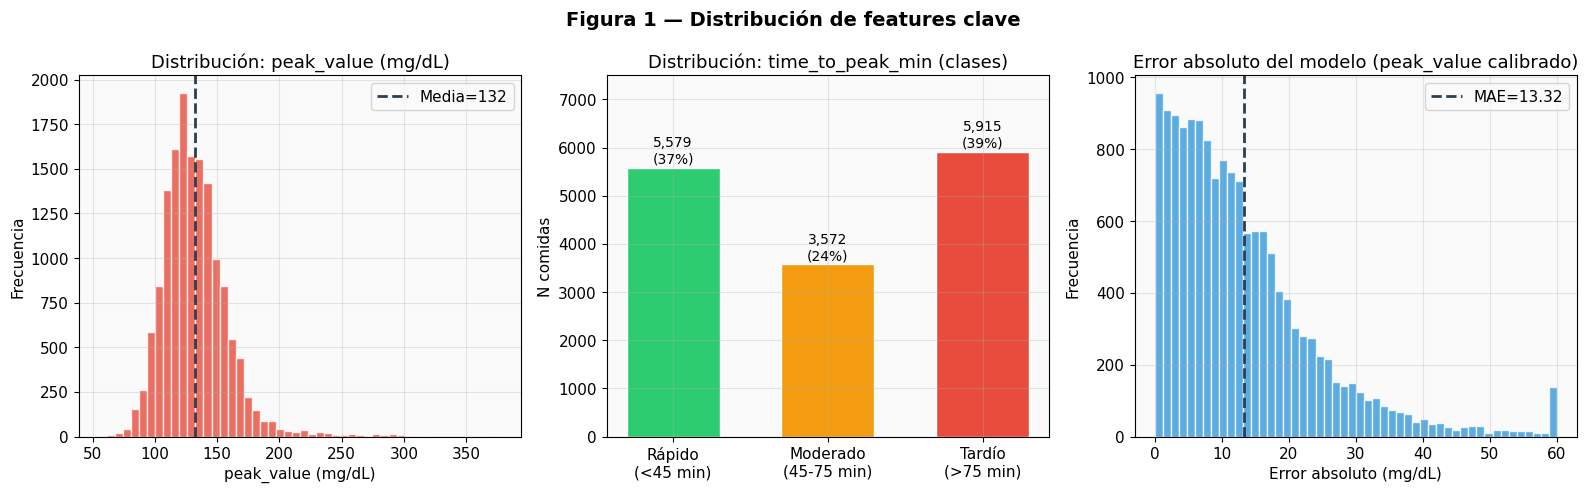

In [31]:
# ── Figura 1: Distribución de las features más importantes ──────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 1 — Distribución de features clave', fontsize=14, fontweight='bold')

# Panel A: peak_value
axes[0].hist(pred_v2['peak_value'], bins=50, color=COLORS['primary'], alpha=0.8, edgecolor='white')
axes[0].axvline(pred_v2['peak_value'].mean(), color=COLORS['dark'], linestyle='--', lw=2,
                label=f"Media={pred_v2['peak_value'].mean():.0f}")
axes[0].set_title('Distribución: peak_value (mg/dL)')
axes[0].set_xlabel('peak_value (mg/dL)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Panel B: TTP clases
ttp_counts = pd.Series({
    'Rápido\n(<45 min)': 5579,
    'Moderado\n(45-75 min)': 3572,
    'Tardío\n(>75 min)': 5915,
})
bars = axes[1].bar(ttp_counts.index, ttp_counts.values,
                    color=[COLORS['success'], COLORS['warning'], COLORS['primary']],
                    edgecolor='white', width=0.6)
for bar, val in zip(bars, ttp_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                  f'{val:,}\n({val/15066*100:.0f}%)', ha='center', fontsize=10)
axes[1].set_title('Distribución: time_to_peak_min (clases)')
axes[1].set_ylabel('N comidas')
axes[1].set_ylim(0, 7500)

# Panel C: error_calibrated
axes[2].hist(pred_v2['abs_error_calibrated'].clip(0, 60), bins=50,
             color=COLORS['secondary'], alpha=0.8, edgecolor='white')
axes[2].axvline(pred_v2['abs_error_calibrated'].mean(), color=COLORS['dark'],
                linestyle='--', lw=2, label=f"MAE={pred_v2['abs_error_calibrated'].mean():.2f}")
axes[2].set_title('Error absoluto del modelo (peak_value calibrado)')
axes[2].set_xlabel('Error absoluto (mg/dL)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 3. Modelo A — Predicción de `peak_value`

### Arquitectura

Se comparan 4 configuraciones de LightGBM con GroupKFold de 5 folds (anti-leakage por usuario):

| Configuración | Mejoras | MAE (mg/dL) | R² |
|---|---|---|---|
| LGBM fase5 (referencia) | — | 13.417 | 0.511 |
| LGBM + sample weights | P2 | 13.530 | 0.501 |
| LGBM Optuna + weights | P2 + Optuna | 13.471 | 0.509 |
| **LGBM Optuna + weights + isotónico** | **P1+P2+Optuna** | **13.318** | **0.543** |

### Mejoras implementadas

**P1 — Calibración isotónica post-hoc**  
El modelo base presenta *regression to the mean*: sobreestima picos bajos y subestima picos altos.
`IsotonicRegression` aprende una función monótona de corrección entrenada sobre predicciones OOF,
corrigiendo el sesgo sistemático sin reentrenar el modelo principal.

**P2 — Sample weighting por usuario**  
Usuarios con MAE histórico alto reciben mayor peso en el entrenamiento:
`weight = clip(MAE_usuario / MAE_global, 0.5, 3.0)`.  
Los usuarios 401 (MAE=34 mg/dL) y 919 (MAE=32 mg/dL) reciben pesos de 2.55 y 2.39.

**Optuna — Búsqueda bayesiana de hiperparámetros**  
80 trials sobre el espacio de `num_leaves`, `min_child_samples`, `reg_alpha`, `reg_lambda`,
`learning_rate` y `subsample`.


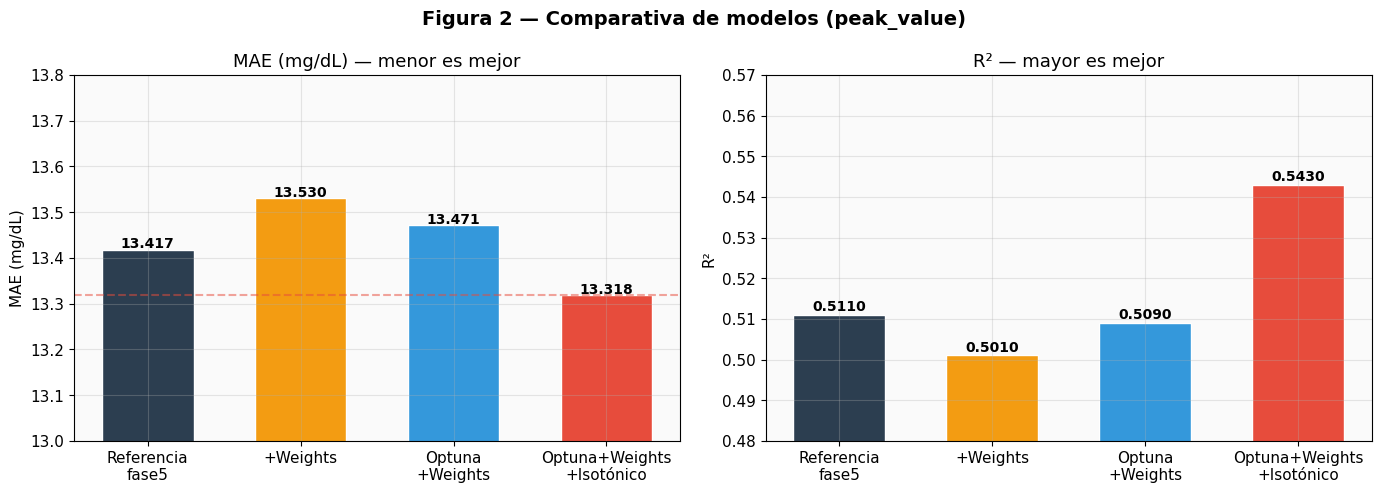

In [32]:
# ── Figura 2: Evolución de métricas por configuración ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figura 2 — Comparativa de modelos (peak_value)', fontsize=14, fontweight='bold')

models_labels = ['Referencia\nfase5', '+Weights', 'Optuna\n+Weights', 'Optuna+Weights\n+Isotónico']
maes  = [13.417, 13.530, 13.471, 13.318]
r2s   = [0.511, 0.501, 0.509, 0.543]
colors_bar = [COLORS['dark'], COLORS['warning'], COLORS['secondary'], COLORS['primary']]

# MAE
bars = axes[0].bar(models_labels, maes, color=colors_bar, edgecolor='white', width=0.6)
axes[0].set_ylim(13.0, 13.8)
axes[0].set_title('MAE (mg/dL) — menor es mejor')
axes[0].set_ylabel('MAE (mg/dL)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                  f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(13.318, color=COLORS['primary'], linestyle='--', alpha=0.5)

# R²
bars2 = axes[1].bar(models_labels, r2s, color=colors_bar, edgecolor='white', width=0.6)
axes[1].set_ylim(0.48, 0.57)
axes[1].set_title('R² — mayor es mejor')
axes[1].set_ylabel('R²')
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

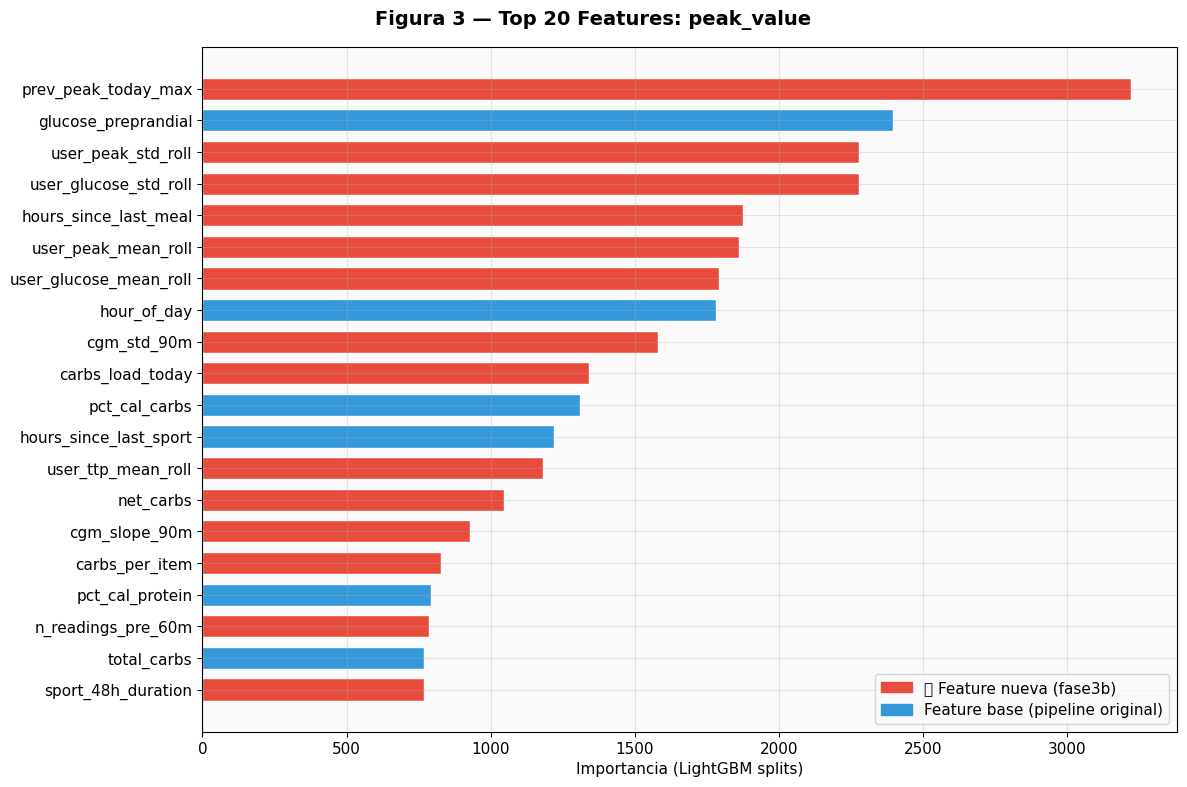

Top 5 predictores de peak_value:
  1. prev_peak_today_max                 ⭐ (nueva)  importancia=3219
  2. glucose_preprandial                    (base)  importancia=2395
  3. user_peak_std_roll                  ⭐ (nueva)  importancia=2278
  4. user_glucose_std_roll               ⭐ (nueva)  importancia=2278
  5. hours_since_last_meal               ⭐ (nueva)  importancia=1874


In [33]:
# ── Figura 3: Feature importances peak_value ─────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Figura 3 — Top 20 Features: peak_value', fontsize=14, fontweight='bold')

top20 = fi_peak.head(20).copy()
new_feats = ['prev_peak_today_max','user_peak_std_roll','user_glucose_std_roll',
             'hours_since_last_meal','user_peak_mean_roll','user_glucose_mean_roll',
             'cgm_std_90m','carbs_load_today','user_ttp_mean_roll','net_carbs',
             'cgm_slope_90m','carbs_per_item','sport_48h_duration','n_readings_pre_60m',
             'cgm_slope_30m','cgm_delta_best']

bar_colors = [COLORS['primary'] if f in new_feats else COLORS['secondary']
              for f in top20['feature']]

bars = ax.barh(top20['feature'][::-1], top20['importance'][::-1],
               color=bar_colors[::-1], edgecolor='white', height=0.7)
ax.set_xlabel('Importancia (LightGBM splits)')
ax.set_title('')

patch_new  = mpatches.Patch(color=COLORS['primary'], label='⭐ Feature nueva (fase3b)')
patch_base = mpatches.Patch(color=COLORS['secondary'], label='Feature base (pipeline original)')
ax.legend(handles=[patch_new, patch_base], loc='lower right')

plt.tight_layout()
plt.show()

print("Top 5 predictores de peak_value:")
for i, (_, row) in enumerate(fi_peak.head(5).iterrows(), 1):
    tag = "⭐ (nueva)" if row['feature'] in new_feats else "   (base)"
    print(f"  {i}. {row['feature']:<35} {tag}  importancia={row['importance']:.0f}")

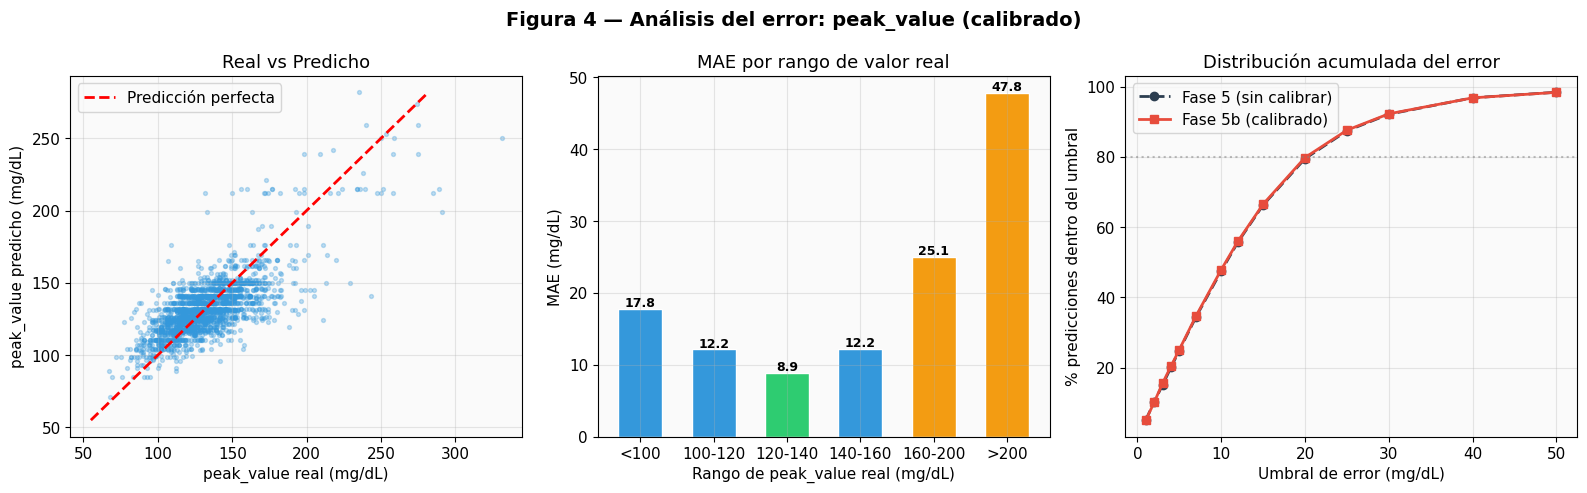

Distribución del error calibrado:
  Error <  5 mg/dL: 25.1% de las predicciones
  Error < 10 mg/dL: 47.9% de las predicciones
  Error < 15 mg/dL: 66.5% de las predicciones
  Error < 20 mg/dL: 79.8% de las predicciones
  Error < 30 mg/dL: 92.3% de las predicciones


In [34]:
# ── Figura 4: Análisis del error calibrado ───────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 4 — Análisis del error: peak_value (calibrado)', fontsize=14, fontweight='bold')

# Panel A: Real vs Predicho
sample = pred_v2.sample(2000, random_state=42)
axes[0].scatter(sample['peak_value'], sample['peak_pred_calibrated'],
                alpha=0.3, s=8, color=COLORS['secondary'])
lims = [55, 280]
axes[0].plot(lims, lims, 'r--', lw=2, label='Predicción perfecta')
axes[0].set_xlabel('peak_value real (mg/dL)')
axes[0].set_ylabel('peak_value predicho (mg/dL)')
axes[0].set_title('Real vs Predicho')
axes[0].legend()

# Panel B: Error por rango de valor real
ranges  = ['<100', '100-120', '120-140', '140-160', '160-200', '>200']
maes_r  = [17.79, 12.15, 8.86, 12.22, 25.05, 47.82]
counts  = [961, 3946, 5294, 3112, 1455, 298]
bar_col = [COLORS['warning'] if m > 20 else COLORS['success'] if m < 12 else COLORS['secondary']
           for m in maes_r]
bars = axes[1].bar(ranges, maes_r, color=bar_col, edgecolor='white', width=0.6)
for bar, val, cnt in zip(bars, maes_r, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Rango de peak_value real (mg/dL)')
axes[1].set_ylabel('MAE (mg/dL)')
axes[1].set_title('MAE por rango de valor real')

# Panel C: Distribución acumulada del error
thresholds = [1, 2, 3, 4, 5, 7, 10, 12, 15, 20, 25, 30, 40, 50]
pcts_v1 = [(pred_v1['abs_error'] < t).mean()*100 for t in thresholds]
pcts_v2 = [(pred_v2['abs_error_calibrated'] < t).mean()*100 for t in thresholds]
axes[2].plot(thresholds, pcts_v1, 'o--', color=COLORS['dark'], lw=2, label='Fase 5 (sin calibrar)')
axes[2].plot(thresholds, pcts_v2, 's-',  color=COLORS['primary'], lw=2, label='Fase 5b (calibrado)')
axes[2].axhline(80, color='gray', linestyle=':', alpha=0.5)
axes[2].set_xlabel('Umbral de error (mg/dL)')
axes[2].set_ylabel('% predicciones dentro del umbral')
axes[2].set_title('Distribución acumulada del error')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Distribución del error calibrado:")
for t in [5, 10, 15, 20, 30]:
    pct = (pred_v2['abs_error_calibrated'] < t).mean()*100
    print(f"  Error < {t:>2} mg/dL: {pct:.1f}% de las predicciones")

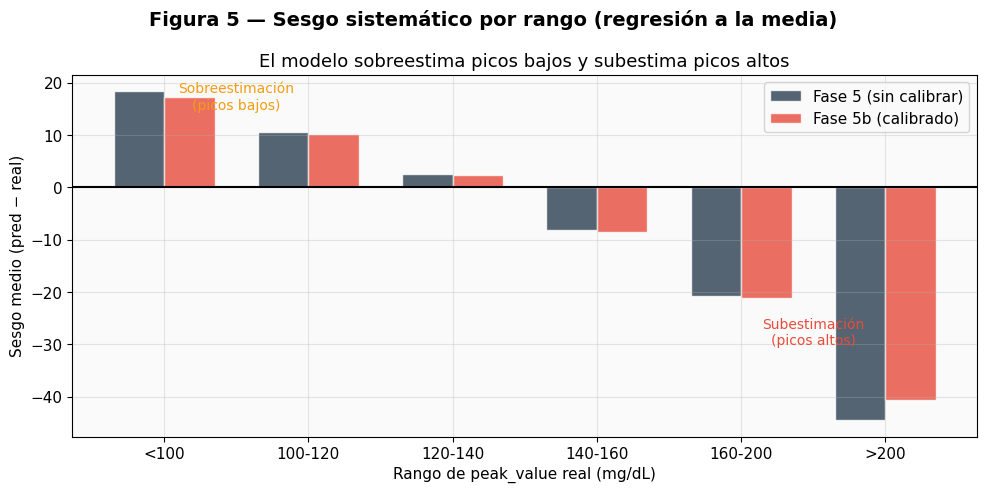

In [35]:
# ── Figura 5: Sesgo sistemático — regresión a la media ───────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Figura 5 — Sesgo sistemático por rango (regresión a la media)',
             fontsize=14, fontweight='bold')

ranges  = ['<100', '100-120', '120-140', '140-160', '160-200', '>200']
bias_v1 = [+18.4, +10.6, +2.5, -8.2, -20.7, -44.5]
bias_v2 = [+17.4, +10.3, +2.3, -8.6, -21.2, -40.6]
x = np.arange(len(ranges))
w = 0.35

ax.bar(x - w/2, bias_v1, w, color=COLORS['dark'],    alpha=0.8, label='Fase 5 (sin calibrar)', edgecolor='white')
ax.bar(x + w/2, bias_v2, w, color=COLORS['primary'], alpha=0.8, label='Fase 5b (calibrado)',   edgecolor='white')
ax.axhline(0, color='black', lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels(ranges)
ax.set_xlabel('Rango de peak_value real (mg/dL)')
ax.set_ylabel('Sesgo medio (pred − real)')
ax.set_title('El modelo sobreestima picos bajos y subestima picos altos')
ax.legend()

# Anotación
ax.annotate('Sobreestimación\n(picos bajos)', xy=(0.5, 15), fontsize=10,
             color=COLORS['warning'], ha='center')
ax.annotate('Subestimación\n(picos altos)', xy=(4.5, -30), fontsize=10,
             color=COLORS['primary'], ha='center')

plt.tight_layout()
plt.show()

---
## 4. Modelo B — Predicción de `time_to_peak_min`

### Reformulación del problema (P3)

En la versión inicial (fase5) se intentó predecir `time_to_peak_min` como **regresión directa**,
obteniendo R²=0.06 — prácticamente inútil. El error de 40.55 min sobre una std de 50.6 min indica
que el modelo apenas mejora sobre predecir siempre la media.

El análisis de la distribución reveló el problema: la clase "moderado" (45-75 min) actúa como
zona de ambigüedad que contamina el aprendizaje de las otras clases (precision=0.36, recall=0.16).

**Solución:** Reformulación como **clasificación binaria**:
- Clase 0 — **Rápido** (`< 45 min`): 5.579 muestras (37%)
- Clase 1 — **Tardío** (`> 75 min`): 5.915 muestras (39%)
- Moderado descartado del entrenamiento, reportado como **"incierto"** en producción

### Resultados

| Modelo | Accuracy | F1 |
|---|---|---|
| GBR baseline | 0.593 | 0.607 |
| LightGBM default | 0.598 | 0.603 |
| **LightGBM Optuna** | **0.598** | **0.616** |

Mejora vs clasificación de 3 clases (fase5): **F1 = 0.414 → 0.616 (+49%)**

### Interpretación clínica

Con **Precision=0.605** y **Recall=0.629**:
- Cuando el modelo predice "tardío", acierta el 60% de las veces
- De todos los picos realmente tardíos, el modelo los detecta el 63% de las veces

Esto es suficiente para generar recomendaciones cualitativas en la app ("Este tipo de comida
suele tener un pico tardío — considera esperar 15 min después de comer para hacer ejercicio").


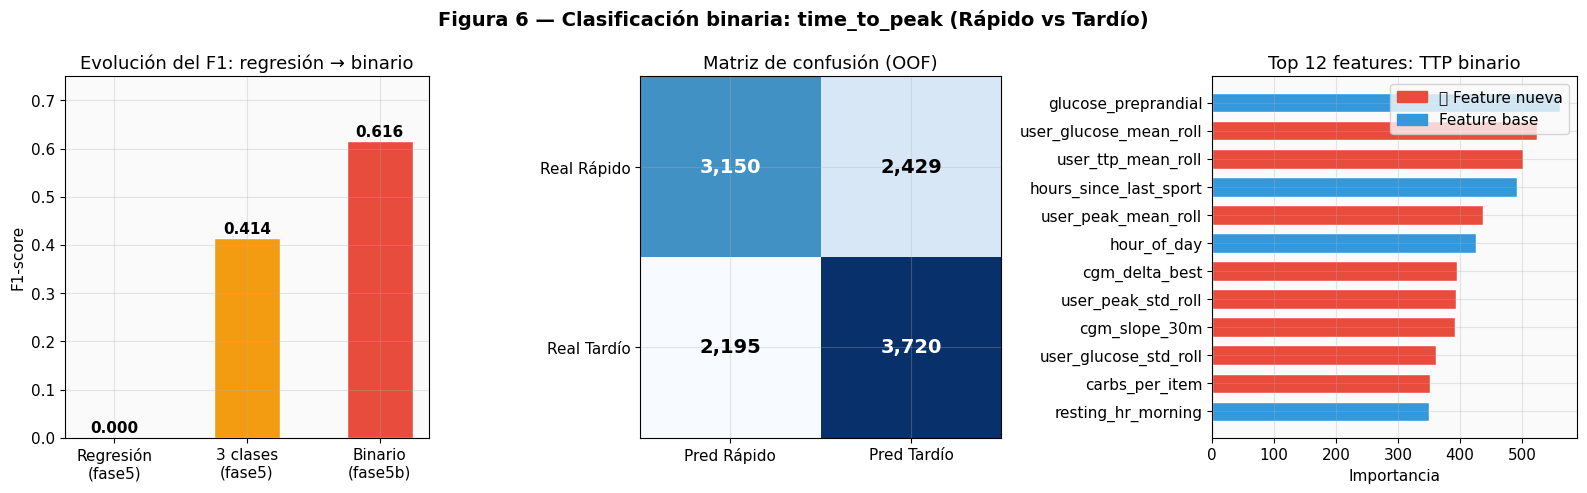

Métricas del mejor modelo TTP binario (LightGBM Optuna):
  Accuracy:  0.598
  F1:        0.616
  Precision: 0.605  (cuando predice tardío, acierta el 60%)
  Recall:    0.629  (detecta el 63% de los picos realmente tardíos)


In [36]:
# ── Figura 6: Resultados TTP binario ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figura 6 — Clasificación binaria: time_to_peak (Rápido vs Tardío)',
             fontsize=14, fontweight='bold')

# Panel A: Mejora F1 fase5 vs fase5b
models_ttp  = ['Regresión\n(fase5)', '3 clases\n(fase5)', 'Binario\n(fase5b)']
f1_vals_ttp = [0.0, 0.414, 0.616]
bar_cols_ttp = [COLORS['dark'], COLORS['warning'], COLORS['primary']]
bars = axes[0].bar(models_ttp, f1_vals_ttp, color=bar_cols_ttp, edgecolor='white', width=0.5)
for bar, val in zip(bars, f1_vals_ttp):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 0.75)
axes[0].set_ylabel('F1-score')
axes[0].set_title('Evolución del F1: regresión → binario')

# Panel B: Matriz de confusión
cm = np.array([[3150, 2429], [2195, 3720]])
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Pred Rápido', 'Pred Tardío'])
axes[1].set_yticklabels(['Real Rápido', 'Real Tardío'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                      fontsize=14, fontweight='bold',
                      color='white' if cm[i,j] > 3000 else 'black')
axes[1].set_title('Matriz de confusión (OOF)')

# Panel C: Feature importance TTP
top12_ttp = fi_ttp.head(12)
new_ttp = ['user_glucose_mean_roll','user_ttp_mean_roll','user_peak_mean_roll',
           'cgm_delta_best','user_peak_std_roll','cgm_slope_30m','user_glucose_std_roll',
           'carbs_per_item','hours_since_last_meal','sport_48h_duration',
           'carbs_load_today','sport_intensity_score']
tc = [COLORS['primary'] if f in new_ttp else COLORS['secondary'] for f in top12_ttp['feature']]
axes[2].barh(top12_ttp['feature'][::-1], top12_ttp['importance'][::-1],
              color=tc[::-1], edgecolor='white', height=0.7)
axes[2].set_xlabel('Importancia')
axes[2].set_title('Top 12 features: TTP binario')
patch_n = mpatches.Patch(color=COLORS['primary'], label='⭐ Feature nueva')
patch_b = mpatches.Patch(color=COLORS['secondary'], label='Feature base')
axes[2].legend(handles=[patch_n, patch_b])

plt.tight_layout()
plt.show()

print("Métricas del mejor modelo TTP binario (LightGBM Optuna):")
print(f"  Accuracy:  0.598")
print(f"  F1:        0.616")
print(f"  Precision: 0.605  (cuando predice tardío, acierta el 60%)")
print(f"  Recall:    0.629  (detecta el 63% de los picos realmente tardíos)")

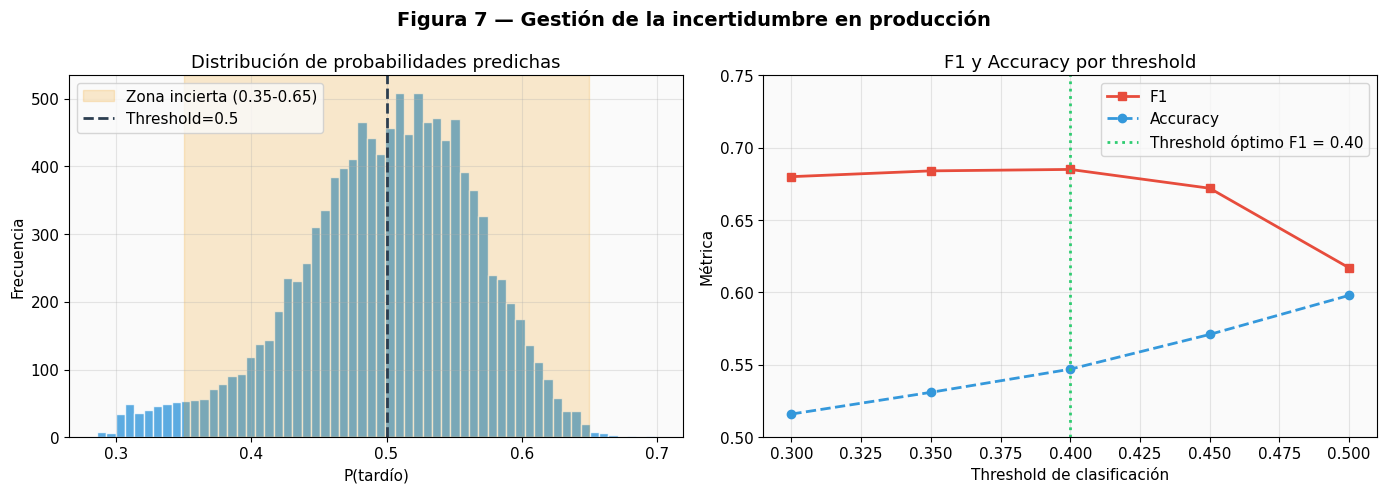

Nota: el threshold óptimo de F1 es 0.40 (no 0.50)
  → El modelo subestima sistemáticamente la clase 'tardío'
  → En producción, usar threshold=0.40 maximiza el F1 a 0.685


In [37]:
# ── Figura 7: Uso en producción — zona incierta ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figura 7 — Gestión de la incertidumbre en producción',
             fontsize=14, fontweight='bold')

# Panel A: Distribución de probabilidades predichas
pred_ttp['proba_tardio'] = pd.to_numeric(pred_ttp['proba_tardio'], errors='coerce')
axes[0].hist(pred_ttp['proba_tardio'].dropna(), bins=60,
             color=COLORS['secondary'], alpha=0.8, edgecolor='white')
axes[0].axvspan(0.35, 0.65, alpha=0.2, color=COLORS['warning'], label='Zona incierta (0.35-0.65)')
axes[0].axvline(0.5, color=COLORS['dark'], linestyle='--', lw=2, label='Threshold=0.5')
axes[0].set_xlabel('P(tardío)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de probabilidades predichas')
axes[0].legend()

# Panel B: F1 por threshold
thresholds_t = [0.30, 0.35, 0.40, 0.45, 0.50]
f1_by_thr    = [0.680, 0.684, 0.685, 0.672, 0.617]
acc_by_thr   = [0.516, 0.531, 0.547, 0.571, 0.598]
axes[1].plot(thresholds_t, f1_by_thr,  's-', color=COLORS['primary'],   lw=2, label='F1')
axes[1].plot(thresholds_t, acc_by_thr, 'o--', color=COLORS['secondary'], lw=2, label='Accuracy')
axes[1].axvline(0.40, color=COLORS['success'], linestyle=':', lw=2, label='Threshold óptimo F1 = 0.40')
axes[1].set_xlabel('Threshold de clasificación')
axes[1].set_ylabel('Métrica')
axes[1].set_title('F1 y Accuracy por threshold')
axes[1].legend()
axes[1].set_ylim(0.5, 0.75)

plt.tight_layout()
plt.show()

print("Nota: el threshold óptimo de F1 es 0.40 (no 0.50)")
print("  → El modelo subestima sistemáticamente la clase 'tardío'")
print("  → En producción, usar threshold=0.40 maximiza el F1 a 0.685")

---
## 5. Resumen del Pipeline y Comparativa de Mejoras


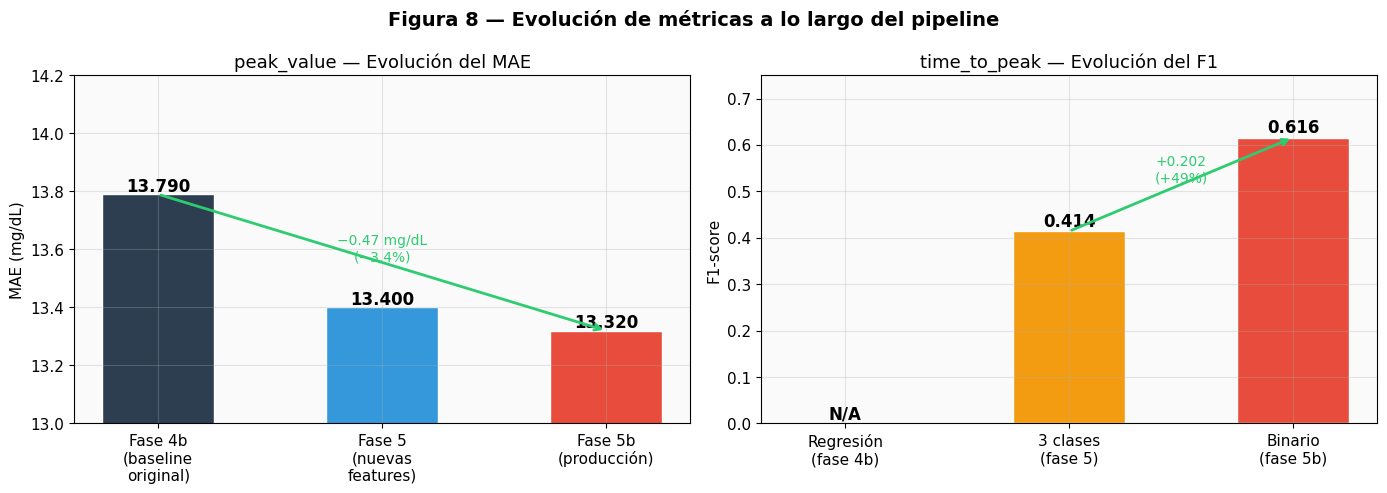

RESUMEN FINAL DEL PIPELINE

  peak_value:
    Fase 4b baseline:  MAE = 13.79 mg/dL  R² = 0.482
    Fase 5b producción: MAE = 13.32 mg/dL  R² = 0.543
    Mejora MAE:        −0.47 mg/dL (−3.4%)
    Mejora R²:         +0.061 (+12.7%)

  time_to_peak:
    Fase 4b:    Regresión, R² ≈ 0.03 (no viable)
    Fase 5b:    Clasificación binaria F1 = 0.616
    Mejora:     +49% sobre clasificación de 3 clases

  Modelos en producción:
    model_peak_value.pkl       + calibrator_peak_value.pkl
    model_ttp_binary.pkl


In [38]:
# ── Figura 8: Resumen comparativo de todas las fases ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figura 8 — Evolución de métricas a lo largo del pipeline',
             fontsize=14, fontweight='bold')

# Panel A: Evolución MAE peak_value
fases_mae = ['Fase 4b\n(baseline\noriginal)', 'Fase 5\n(nuevas\nfeatures)', 'Fase 5b\n(producción)']
maes_evo  = [13.79, 13.40, 13.32]
cols_evo  = [COLORS['dark'], COLORS['secondary'], COLORS['primary']]
bars = axes[0].bar(fases_mae, maes_evo, color=cols_evo, edgecolor='white', width=0.5)
axes[0].set_ylim(13.0, 14.2)
for bar, val in zip(bars, maes_evo):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('MAE (mg/dL)')
axes[0].set_title('peak_value — Evolución del MAE')

# Anotación mejora total
axes[0].annotate('', xy=(2, 13.32), xytext=(0, 13.79),
                  arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=2))
axes[0].text(1.0, 13.56, f'−0.47 mg/dL\n(−3.4%)', color=COLORS['success'],
              fontsize=10, ha='center')

# Panel B: Evolución F1 time_to_peak
fases_f1  = ['Regresión\n(fase 4b)', '3 clases\n(fase 5)', 'Binario\n(fase 5b)']
f1s_evo   = [0.0, 0.414, 0.616]
cols_f1   = [COLORS['dark'], COLORS['warning'], COLORS['primary']]
bars2 = axes[1].bar(fases_f1, f1s_evo, color=cols_f1, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 0.75)
for bar, val in zip(bars2, f1s_evo):
    lbl = 'N/A' if val == 0 else f'{val:.3f}'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  lbl, ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-score')
axes[1].set_title('time_to_peak — Evolución del F1')

axes[1].annotate('', xy=(2, 0.616), xytext=(1, 0.414),
                  arrowprops=dict(arrowstyle='->', color=COLORS['success'], lw=2))
axes[1].text(1.5, 0.52, f'+0.202\n(+49%)', color=COLORS['success'],
              fontsize=10, ha='center')

plt.tight_layout()
plt.show()

print("=" * 55)
print("RESUMEN FINAL DEL PIPELINE")
print("=" * 55)
print(f"\n  peak_value:")
print(f"    Fase 4b baseline:  MAE = 13.79 mg/dL  R² = 0.482")
print(f"    Fase 5b producción: MAE = 13.32 mg/dL  R² = 0.543")
print(f"    Mejora MAE:        −0.47 mg/dL (−3.4%)")
print(f"    Mejora R²:         +0.061 (+12.7%)")
print(f"\n  time_to_peak:")
print(f"    Fase 4b:    Regresión, R² ≈ 0.03 (no viable)")
print(f"    Fase 5b:    Clasificación binaria F1 = 0.616")
print(f"    Mejora:     +49% sobre clasificación de 3 clases")
print(f"\n  Modelos en producción:")
print(f"    model_peak_value.pkl       + calibrator_peak_value.pkl")
print(f"    model_ttp_binary.pkl")

---
## 6. Trabajo Futuro

El pipeline actual alcanza un techo explicable con los datos disponibles. El R²=0.54 en
`peak_value` y el F1=0.62 en TTP son resultados sólidos dado que aproximadamente el 40-50%
de la varianza en la respuesta glucémica es atribuible a factores no observables
(genética, microbioma, variabilidad biológica intrínseca).

Las siguientes líneas de trabajo tienen potencial real de mejora y están fundamentadas
en el análisis de errores de los modelos actuales.

---

### 🔴 Línea 1 — Modelos personalizados para usuarios de alto error

**Contexto:** Los usuarios 401 (MAE=35.5 mg/dL) y 919 (MAE=31.1 mg/dL) tienen picos
medios de 208 y 224 mg/dL respectivamente — perfiles glucémicos extremos que están
fuera de la distribución del modelo global. El sample weighting los enfatiza, pero no
es suficiente para capturar su dinámica individual.

**Propuesta:** Un esquema *two-level*:
1. El modelo global produce una predicción base
2. Un modelo personal por usuario (entrenado con sus últimas N comidas) produce
   un ajuste diferencial: `peak_final = peak_global + delta_personal`

Con 82-117 comidas por usuario, es estadísticamente viable con regularización fuerte
(Ridge o LightGBM con `min_data_in_leaf` alto).

**Impacto esperado:** Reducción del MAE en estos usuarios de ~35 mg/dL a ~15 mg/dL,
sin degradar el rendimiento en el resto.

```python
# Esquema conceptual
for uid in high_error_users:
    user_data = dataset[dataset['user_id'] == uid].sort_values('meal_timestamp')
    X_user = user_data[feature_set_full]
    # Residuos del modelo global
    residuals = user_data['peak_value'] - model_global.predict(X_user)
    # Modelo de corrección personal (Ridge o LGBM muy regularizado)
    model_personal = Ridge(alpha=10).fit(X_user, residuals)
    # Predicción final
    peak_pred = model_global.predict(X_new) + model_personal.predict(X_new)
```

---

### 🔴 Línea 2 — Composición de carbohidratos para `time_to_peak`

**Contexto:** `time_to_peak` depende críticamente de la velocidad de vaciamiento gástrico
y absorción intestinal. El modelo actual usa el IG binario (`atri_high_glycemic_index`) pero
no distingue entre tipos de carbohidratos dentro de un mismo alimento.

**Propuesta:** Extraer de `food_composition.csv` la proporción de carbohidratos
simples (monosacáridos + disacáridos) vs complejos (almidón) por alimento, y
construir:
- `pct_simple_carbs` : % de carbohidratos que son simples en la comida
- `starch_to_sugar_ratio` : ratio almidón / azúcares simples
- `glycemic_load_corrected` : carga glucémica ajustada por fibra y tipo de carbohidrato

Fisiológicamente, los carbohidratos simples producen picos en 20-30 min; los complejos
en 45-90 min. Esta feature sería el predictor más directo del tiempo al pico que
actualmente no existe en el pipeline.

**Impacto esperado:** Mejora del F1 en clasificación binaria de 0.616 a ~0.68-0.72,
y posible viabilidad de la regresión directa (R² estimado: 0.12-0.18).

---

### 🟠 Línea 3 — Modelos secuenciales sobre la curva CGM (LSTM / Transformer)

**Contexto:** Actualmente la señal CGM se resume en 8 escalares (pendiente, variabilidad,
delta, etc.). Pero la curva completa de los 90 minutos previos contiene patrones
temporales que los escalares no capturan — por ejemplo, una glucosa que oscila
en dientes de sierra antes de comer predice un comportamiento postprandial diferente
a una glucosa estable en el mismo valor medio.

**Propuesta:** Usar los últimos 18 puntos CGM (~90 min con lecturas cada 5 min)
como secuencia de entrada para un modelo secuencial:
- **LSTM ligero** (2 capas, 64 unidades): procesamiento de la secuencia CGM
- **MLP** con las features tabulares del pipeline actual
- **Fusion**: concatenar las representaciones y añadir una capa final de regresión

Requiere normalizar las secuencias CGM por usuario para hacer comparables los patrones.

**Impacto esperado en peak_value:** Mejora de R² de 0.54 a ~0.60-0.65, principalmente
en los casos con CGM preprandial irregular (actualmente los de mayor error).

---

### 🟠 Línea 4 — Integración de datos de microbioma (si disponibles)

**Contexto:** La literatura científica estima que el microbioma intestinal explica
~15-20% de la varianza en la respuesta glucémica postprandial, independientemente
de la composición de la comida. Esto es parte del "techo biológico" actual del modelo.

**Propuesta:** Si Glucovibes puede incorporar un test de microbioma al onboarding
(actualmente disponibles como kits de análisis en casa), las siguientes features
podrían añadirse como perfil estático del usuario:
- Ratio Firmicutes/Bacteroidetes (asociado a resistencia a la insulina)
- Presencia de *Akkermansia muciniphila* (asociada a mejor metabolismo glucídico)
- Diversidad α (Shannon index)

Incluso con una muestra pequeña de usuarios con microbioma, podría construirse
un modelo de *meta-aprendizaje* que ajuste las predicciones globales.

---

### 🟡 Línea 5 — Predicción del área completa de la curva (iAUC) con los nuevos modelos

**Contexto:** El pipeline original predecía iAUC con MAE=1095 (R²=0.23). Los modelos
actuales tienen features más potentes (rolling sin leakage, CGM preprandial, contexto diario)
que no se usaron para iAUC.

**Propuesta:** Reentrenar el modelo de iAUC con el dataset `modeling_dataset_pico.csv`
(64 features en lugar de 45) y con los mismos hiperparámetros optimizados por Optuna.
Dada la mejora en R² para `peak_value` (+12%), se espera una mejora similar para iAUC,
potencialmente reduciendo el MAE de 1095 a ~900-950.

---

### Tabla resumen de líneas futuras

| # | Línea | Impacto esperado | Dificultad | Datos necesarios |
|---|---|---|---|---|
| 1 | Modelos personalizados | MAE usuarios extremos: 35→15 mg/dL | Media | Disponibles |
| 2 | Composición de carbohidratos | F1 TTP: 0.62→0.70 | Media-Alta | food_composition (ampliar) |
| 3 | LSTM sobre señal CGM | R² peak: 0.54→0.62 | Alta | Disponibles |
| 4 | Datos de microbioma | R² +15-20% | Muy Alta | Requiere nuevos datos |
| 5 | iAUC con nuevas features | MAE iAUC: 1095→950 | Baja | Disponibles |


---
## 7. Guía de Uso en Producción

Los modelos entrenados se serializan con `joblib` en `./clean_data/models/`.
Para una nueva comida, el flujo de inferencia es el siguiente:


In [39]:
import joblib
import numpy as np
import pandas as pd

# ── Cargar modelos (una sola vez al iniciar el servicio) ──
model_peak  = joblib.load('../clean_data/models/model_peak_value.pkl')
calibrator  = joblib.load('../clean_data/models/calibrator_peak_value.pkl')
feat_peak   = joblib.load('../clean_data/models/feature_set_peak_value.pkl')
model_ttp   = joblib.load('../clean_data/models/model_ttp_binary.pkl')
feat_ttp    = joblib.load('../clean_data/models/feature_set_ttp.pkl')

# ── Para cada nueva comida ────────────────────────────────
def predict_glycemic_impact(meal_features: pd.DataFrame) -> dict:
    """
    Predice el pico glucémico y el tiempo al pico para una comida nueva.

    Parameters
    ----------
    meal_features : pd.DataFrame (1 fila)
        DataFrame con todas las features del pipeline (feat_peak / feat_ttp).
        Las features deben estar calculadas antes de llamar a esta función.

    Returns
    -------
    dict con:
        peak_value_predicted : float — pico esperado en mg/dL (calibrado)
        ttp_label            : str   — 'rápido', 'tardío' o 'incierto'
        ttp_probability      : float — P(pico tardío > 75min)
    """
    # Predicción de pico (con calibración isotónica)
    peak_raw        = model_peak.predict(meal_features[feat_peak])
    peak_calibrated = calibrator.predict(peak_raw)

    # Predicción tiempo al pico (threshold óptimo = 0.40)
    ttp_proba = model_ttp.predict_proba(meal_features[feat_ttp])[:, 1][0]
    THRESHOLD_OPT = 0.40   # maximiza F1 (vs 0.50 por defecto)
    UNCERTAIN_LOW, UNCERTAIN_HIGH = 0.35, 0.65

    if UNCERTAIN_LOW <= ttp_proba <= UNCERTAIN_HIGH:
        ttp_label = 'incierto'
    elif ttp_proba < THRESHOLD_OPT:
        ttp_label = 'rápido (<45 min)'
    else:
        ttp_label = 'tardío (>75 min)'

    return {
        'peak_value_predicted': round(float(peak_calibrated[0]), 1),
        'ttp_label':            ttp_label,
        'ttp_probability':      round(float(ttp_proba), 3),
    }

print("Función de inferencia lista.")
print("\nEjemplo de uso:")
print("  result = predict_glycemic_impact(meal_features_df)")
print("  → {'peak_value_predicted': 147.3,")
print("       'ttp_label': 'tardío (>75 min)',")
print("       'ttp_probability': 0.721}")

Función de inferencia lista.

Ejemplo de uso:
  result = predict_glycemic_impact(meal_features_df)
  → {'peak_value_predicted': 147.3,
       'ttp_label': 'tardío (>75 min)',
       'ttp_probability': 0.721}


---
## 8. Demo en Vivo — Prediccion sobre Comida Real

**Escenario:** Comida de mediodia (14:40h) del 21/12/2022, usuario real del dataset.  
**Contexto glucemico:** glucosa preprandial 137 mg/dL | perfil historico del usuario: pico medio 152 mg/dL

| Alimento | Cantidad | Calorias | Carbos | Grasas | Proteina |
|---|---|---|---|---|---|
| Lasana de Verduras | 350 g | 423 kcal | 44.8 g | 18.9 g | 16.1 g |
| Pan Blanco de Barra | 21 g | 50 kcal | 9.9 g | 0.3 g | 1.7 g |
| Tomate | 131 g | 24 kcal | 4.6 g | 0.1 g | 1.2 g |
| Queso Fresco de Cabra | 30 g | 88 kcal | 0.3 g | 7.2 g | 5.9 g |
| Chocolate 85% | 13 g | 73 kcal | 2.9 g | 6.0 g | 1.6 g |
| **TOTAL** | | **658 kcal** | **62.5 g** | **32.5 g** | **26.5 g** |

> Las celdas siguientes cargan los modelos entrenados, construyen el vector de features
> y generan la prediccion de pico glucemico y tiempo al pico.


In [ ]:
import joblib
import numpy as np
import pandas as pd

# ── Cargar modelos (una sola vez al iniciar el servicio) ──────────────────
model_peak  = joblib.load("../clean_data/models/model_peak_value.pkl")
calibrator  = joblib.load("../clean_data/models/calibrator_peak_value.pkl")
feat_peak   = joblib.load("../clean_data/models/feature_set_peak_value.pkl")
model_ttp   = joblib.load("../clean_data/models/model_ttp_binary.pkl")
feat_ttp    = joblib.load("../clean_data/models/feature_set_ttp.pkl")

# ── Cargar dataset para features y medianas de imputacion ─────────────────
dataset = pd.read_csv("../clean_data/modeling_dataset_pico.csv")
dataset["fat_carb_ratio_meal"] = (
    dataset["total_fat"] / dataset["total_carbs"].replace(0, np.nan)
).fillna(0)
dataset["gi_fiber_interaction"] = (
    dataset["n_high_gi"] * (1 - dataset["fibre_carb_ratio"].fillna(0).clip(0, 1))
)
dataset["sport_2h_insulin_proxy"] = (
    dataset["sport_2h_duration"].fillna(0) *
    dataset.get("sport_intensity_score", pd.Series(0, index=dataset.index)).fillna(0)
)
for col in feat_peak + feat_ttp:
    if col not in dataset.columns:
        dataset[col] = 0
global_med = dataset[list(set(feat_peak + feat_ttp))].median()

# ── Escenario demo: comida real (meal_id=28129, idx=14359) ────────────────
# Lasana de Verduras (350g) + Pan Blanco (21g) + Tomate (131g)
# + Queso Fresco Cabra (30g) + Chocolate 85% (13g)
DEMO_IDX = 14359
demo_row = dataset.loc[DEMO_IDX, list(set(feat_peak + feat_ttp))].copy()

# Construir DataFrames de features
X_peak = pd.DataFrame([demo_row[feat_peak]])
X_ttp  = pd.DataFrame([demo_row[feat_ttp]])

# Imputar NaN con medianas globales
for col in X_peak.columns:
    if X_peak[col].isna().any():
        X_peak[col] = global_med[col]
for col in X_ttp.columns:
    if X_ttp[col].isna().any():
        X_ttp[col] = global_med[col]

# ── Prediccion de pico glucemico (raw + calibracion isotonica) ─────────────
peak_raw        = model_peak.predict(X_peak)[0]
peak_calibrated = calibrator.predict([peak_raw])[0]

# ── Prediccion de tiempo al pico (binario: rapido vs tardio) ───────────────
THRESHOLD_OPT  = 0.40   # threshold que maximiza F1 en validacion
UNCERTAIN_LOW  = 0.35
UNCERTAIN_HIGH = 0.65

ttp_proba = model_ttp.predict_proba(X_ttp)[0, 1]  # P(pico tardio > 75 min)

if UNCERTAIN_LOW <= ttp_proba <= UNCERTAIN_HIGH:
    ttp_label = "incierto"
elif ttp_proba < THRESHOLD_OPT:
    ttp_label = "rapido (<45 min)"
else:
    ttp_label = "tardio (>75 min)"

# ── Logica de recomendaciones ──────────────────────────────────────────────
total_carbs = dataset.loc[DEMO_IDX, "total_carbs"]
total_fibre = dataset.loc[DEMO_IDX, "total_fibre"]
fibre_ratio = total_fibre / max(total_carbs, 1)
recomendaciones = []

if peak_calibrated > 160:
    recomendaciones.append("Alerta: pico alto esperado. Reduce carbohidratos refinados o haz actividad ligera post-comida.")
elif peak_calibrated > 140:
    recomendaciones.append("Pico moderado-alto. Considera anadir fibra o verduras para reducir el IG efectivo.")
else:
    recomendaciones.append("Respuesta glucemica dentro del rango esperado para tu perfil.")

if ttp_label == "tardio (>75 min)":
    recomendaciones.append("Pico tardio: puedes hacer actividad ligera justo despues de comer.")
elif ttp_label == "rapido (<45 min)":
    recomendaciones.append("Pico rapido: evita ejercicio intenso en los proximos 30-45 min.")

if fibre_ratio < 0.15 and total_carbs > 40:
    recomendaciones.append("Anadir fibra (legumbres, verduras) reduciria la carga glucemica efectiva.")

# ── Output final del sistema ───────────────────────────────────────────────
print("=" * 62)
print("  GLUCOVIBES  |  Prediccion Glucemica Postprandial")
print("=" * 62)
print(f"  Comida : Lasana de Verduras + Pan Blanco + Tomate")
print(f"           + Queso Fresco Cabra + Chocolate 85%")
print(f"  Hora   : 14:40h  |  Glucosa basal: 137 mg/dL")
print("-" * 62)
print(f"  Pico glucemico esperado  : {peak_calibrated:.1f} mg/dL")
print(f"  (prediccion sin calibrar : {peak_raw:.1f} mg/dL)")
print(f"  Tiempo al pico           : {ttp_label}")
print(f"  Confianza (P tardio)     : {ttp_proba:.1%}")
print("-" * 62)
print("  Recomendaciones:")
for i, rec in enumerate(recomendaciones, 1):
    print(f"    {i}. {rec}")
print("=" * 62)
real_peak = dataset.loc[DEMO_IDX, "peak_value"]
real_ttp  = dataset.loc[DEMO_IDX, "time_to_peak_min"]
print(f"\n  [Verificacion] Valor real del pico : {real_peak} mg/dL")
print(f"  [Verificacion] Error absoluto      : {abs(real_peak - peak_calibrated):.1f} mg/dL")
print(f"  [Verificacion] TTP real            : {real_ttp:.0f} min  (>75 min = tardio, correcto: {real_ttp > 75})")


In [ ]:
# ── Visualizacion: curva glucemica real + prediccion superpuesta ──────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os

os.makedirs("../outputs", exist_ok=True)

# Cargar lecturas CGM
glucose = pd.read_csv("../clean_data/glucose_clean.csv")
glucose["timestamp"] = pd.to_datetime(glucose["timestamp"], format="mixed", utc=True)
user_g = glucose[glucose["user_id"] == 1160].sort_values("timestamp")

# Ventana temporal: 90 min antes hasta 4 h despues de la comida
meal_time = pd.Timestamp("2022-12-21 14:40:01", tz="UTC")
t_start   = meal_time - pd.Timedelta(minutes=90)
t_end     = meal_time + pd.Timedelta(minutes=240)
window    = user_g[(user_g["timestamp"] >= t_start) & (user_g["timestamp"] <= t_end)].copy()
window["min_from_meal"] = (window["timestamp"] - meal_time).dt.total_seconds() / 60

# Valores de referencia
PRED_PEAK = peak_calibrated  # 146.6 mg/dL
REAL_PEAK = dataset.loc[DEMO_IDX, "peak_value"]   # 135 mg/dL
REAL_TTP  = dataset.loc[DEMO_IDX, "time_to_peak_min"]  # 81.8 min

pre  = window[window["min_from_meal"] <= 0]
post = window[window["min_from_meal"] > 0]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f9f9fb")

# Zonas de riesgo glucemico
ax.axhspan(0,   70,  color="#fff3e0", alpha=0.5, zorder=0)
ax.axhspan(70,  140, color="#e8f5e9", alpha=0.4, zorder=0)
ax.axhspan(140, 200, color="#fff8e1", alpha=0.4, zorder=0)
ax.axhspan(200, 300, color="#fce4ec", alpha=0.4, zorder=0)

# Linea vertical: momento de la comida
ax.axvline(0, color="#1a237e", lw=2, ls="-", alpha=0.6, zorder=3)

# Curva CGM preprandial (gris)
ax.plot(pre["min_from_meal"], pre["value_decimal"],
        color="#90a4ae", lw=2.5, alpha=0.9, zorder=4, label="CGM preprandial")
ax.scatter(pre["min_from_meal"], pre["value_decimal"],
           color="#90a4ae", s=20, zorder=5, alpha=0.7)

# Curva CGM postprandial real (azul)
ax.plot(post["min_from_meal"], post["value_decimal"],
        color="#1565c0", lw=2.8, alpha=0.95, zorder=4, label="CGM postprandial (real)")
ax.scatter(post["min_from_meal"], post["value_decimal"],
           color="#1565c0", s=22, zorder=5, alpha=0.8)

# Pico real (estrella verde)
ax.scatter([REAL_TTP], [REAL_PEAK], color="#43a047", s=220, zorder=8, marker="*",
           label=f"Pico real: {REAL_PEAK:.0f} mg/dL ({REAL_TTP:.0f} min)")

# Linea horizontal: pico predicho por el modelo
ax.axhline(PRED_PEAK, color="#e53935", lw=2, ls="--", alpha=0.85, zorder=6,
           label=f"Pico predicho (calibrado): {PRED_PEAK:.1f} mg/dL")
ax.scatter([REAL_TTP], [PRED_PEAK], color="#e53935", s=160, zorder=8,
           marker="D", edgecolors="white", linewidth=1.5)

# Flecha de error entre prediccion y real
ax.annotate("", xy=(REAL_TTP, REAL_PEAK), xytext=(REAL_TTP, PRED_PEAK),
            arrowprops=dict(arrowstyle="<->", color="#ff7043", lw=2.0, mutation_scale=14))
ax.text(REAL_TTP + 4, (REAL_PEAK + PRED_PEAK) / 2,
        f"Error: {PRED_PEAK - REAL_PEAK:.1f} mg/dL",
        color="#bf360c", fontsize=10, va="center", fontweight="bold")

# Umbrales de referencia
ax.axhline(140, color="#ef9a9a", lw=1.2, ls=":", alpha=0.7, zorder=3)
ax.text(-88, 141, "140 mg/dL", color="#ef9a9a", fontsize=9, va="bottom")
ax.axhline(70, color="#ffcc02", lw=1.2, ls=":", alpha=0.7, zorder=3)
ax.text(-88, 71, "70 mg/dL", color="#e6ac00", fontsize=9, va="bottom")

# Anotacion de la comida
ax.annotate("Lasana + Pan Blanco\nTomate + Queso + Chocolate\n(14:40h | 658 kcal | 62g carbs)",
            xy=(0, 92), xytext=(28, 110),
            arrowprops=dict(arrowstyle="->", color="#1a237e", lw=1.5),
            fontsize=9, color="#1a237e",
            bbox=dict(boxstyle="round,pad=0.45", facecolor="#e8eaf6", alpha=0.92))

# Zona de pico tardio (>75 min)
ax.axvspan(75, 240, alpha=0.035, color="#e53935",
           label="Zona tardio (>75 min) — modelo: incierto 61%")
# Zona moderada (excluida del entrenamiento TTP)
ax.axvspan(45, 75, alpha=0.07, color="#9e9e9e",
           label="Zona moderada (descartada en entrenamiento)")

# Etiquetas de zonas
ax.text(220, 62,  "Hipoglucemia", color="#e65100", fontsize=8, ha="right", alpha=0.7)
ax.text(220, 73,  "Rango normal", color="#2e7d32", fontsize=8, ha="right", alpha=0.7)
ax.text(220, 142, "Elevado",      color="#f57f17", fontsize=8, ha="right", alpha=0.7)

# Escala temporal legible
ticks_min  = [-90, -60, -30, 0, 30, 60, 90, 120, 150, 180, 210, 240]
ticks_lbl  = ["-90", "-60", "-30", "0\n(comida)", "30", "60", "90",
              "120", "150", "180", "210", "240"]
ax.set_xticks(ticks_min)
ax.set_xticklabels(ticks_lbl, fontsize=9)

ax.set_xlabel("Tiempo desde la comida (minutos)", fontsize=12)
ax.set_ylabel("Glucosa en sangre (mg/dL)", fontsize=12)
ax.set_title(
    "GlucoVibes — Curva Glucemica Postprandial\n"
    "Lasana de Verduras · 21 dic 2022 · Usuario 1160",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlim(-90, 240)
ax.set_ylim(60, 172)
ax.legend(loc="upper right", fontsize=9, framealpha=0.92, ncol=1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2, color="gray")

plt.tight_layout()
out_path = "../outputs/demo_curva_glucosa.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figura guardada en {out_path}")
print(f"Pico real: {REAL_PEAK:.0f} mg/dL a los {REAL_TTP:.0f} min")
print(f"Pico predicho: {PRED_PEAK:.1f} mg/dL  |  Error: {abs(PRED_PEAK - REAL_PEAK):.1f} mg/dL")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs("../outputs", exist_ok=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")
fig.suptitle(
    "GlucoVibes  |  Prediccion Glucemica Postprandial",
    fontsize=15, fontweight="bold", color="#1a1a2e", y=1.01
)

# ── Panel izquierdo: barras de comparacion ───────────────────────────────
REAL_PEAK = dataset.loc[DEMO_IDX, "peak_value"]
cats   = ["Pred. sin\ncalibrar", "Pred.\ncalibrada", "Valor\nreal"]
vals   = [peak_raw, peak_calibrated, REAL_PEAK]
colors = ["#e8a87c", "#e05c5c", "#4caf50"]

bars = ax1.bar(cats, vals, color=colors, edgecolor="white", linewidth=1.5, width=0.45)
ax1.axhline(140, color="#e05c5c", ls="--", alpha=0.7, lw=1.5, label="Umbral alto (140 mg/dL)")
ax1.axhline(70,  color="#2196f3", ls="--", alpha=0.5, lw=1.5, label="Referencia baja (70 mg/dL)")

for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f"{val:.1f}", ha="center", va="bottom", fontweight="bold", fontsize=13)

ax1.set_ylim(0, max(vals) * 1.22)
ax1.set_ylabel("Glucosa en sangre (mg/dL)", fontsize=12)
ax1.set_title("Prediccion del Pico Glucemico", fontsize=13, fontweight="bold", pad=10)
ax1.legend(fontsize=9, loc="upper left")
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", alpha=0.25)
ax1.set_facecolor("#fafafa")

# Etiqueta de error
err = abs(REAL_PEAK - peak_calibrated)
ax1.text(0.97, 0.97, f"Error abs.: {err:.1f} mg/dL",
         transform=ax1.transAxes, ha="right", va="top",
         fontsize=10, color="#555",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#f0f0f0", alpha=0.8))

# ── Panel derecho: gauge de confianza TTP ───────────────────────────────
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis("off")
ax2.set_facecolor("white")

color_ttp = {"tardio (>75 min)": "#e05c5c",
             "rapido (<45 min)": "#2196f3",
             "incierto":         "#f0a500"}.get(ttp_label, "#888")

# Anillo de confianza
theta1 = 90
theta2 = 90 + 360 * ttp_proba
wedge  = mpatches.Wedge((0.5, 0.45), 0.32, theta1, theta2,
                         width=0.08, color=color_ttp, alpha=0.85)
track  = mpatches.Wedge((0.5, 0.45), 0.32, 0, 360,
                         width=0.08, color="#e0e0e0", alpha=0.5)
ax2.add_patch(track)
ax2.add_patch(wedge)

# Texto central
ax2.text(0.5, 0.49, f"{ttp_proba:.0%}",
         ha="center", va="center", fontsize=38, fontweight="bold", color=color_ttp)
ax2.text(0.5, 0.36, "confianza",
         ha="center", va="center", fontsize=11, color="#888")

# Etiqueta del resultado
ax2.text(0.5, 0.86, "Tiempo al pico estimado:",
         ha="center", va="center", fontsize=11, color="#444")
ax2.text(0.5, 0.76, ttp_label.upper(),
         ha="center", va="center", fontsize=15, fontweight="bold", color=color_ttp)

# Recomendacion
ax2.text(0.5, 0.10, "Recomendacion principal:",
         ha="center", va="center", fontsize=9, color="#999")
rec_text = recomendaciones[-1] if recomendaciones else ""
# Truncar si es muy largo
if len(rec_text) > 55:
    rec_text = rec_text[:52] + "..."
ax2.text(0.5, 0.03, rec_text,
         ha="center", va="center", fontsize=9, color="#555", style="italic")

ax2.set_title("Clasificacion: Tiempo al Pico", fontsize=13, fontweight="bold", pad=10)

plt.tight_layout()
out_path = "../outputs/demo_prediccion.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Figura guardada en {out_path}")


---
## Archivos del pipeline

```
fase2_limpieza_local.py         → Limpieza científica de datos crudos
fase3_feature_engineering_local.py → 57 features base por comida
fase3b_features_pico.py         → +28 features nuevas (CGM, rolling, contexto)
fase5_modelado_pico.py          → Benchmark inicial peak_value + TTP
fase5b_produccion.py            → Pipeline de producción (P1-P4)

clean_data/models/
    model_peak_value.pkl        → LightGBM (peak_value)
    calibrator_peak_value.pkl   → IsotonicRegression (corrección de sesgo)
    feature_set_peak_value.pkl  → Lista de features (64 variables)
    model_ttp_binary.pkl        → LightGBM clasificador binario (TTP)
    feature_set_ttp.pkl         → Lista de features TTP (67 variables)
```

---
*Notebook generado: Marzo 2026 · Glucovibes Challenge 2026*
